Loading the data processed by hdWGCNA in R

In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Isocortex-1"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
ENSMUSG00000015090,ENSMUSG00000015090,Isocortex-M1,yellow,0.645442,-0.082131,0.055263,0.123491,-0.087391,0.096088,0.129945,0.244009,0.606363,-0.205105
ENSMUSG00000031425,ENSMUSG00000031425,Isocortex-M1,yellow,0.919267,-0.107151,0.070567,0.095239,-0.112462,0.107643,0.243849,0.051845,0.041710,-0.244151
ENSMUSG00000115529,ENSMUSG00000115529,Isocortex-M1,yellow,0.290416,-0.025055,0.009020,0.027299,-0.029463,0.038628,0.236592,0.012456,0.003026,-0.099603
ENSMUSG00000029819,ENSMUSG00000029819,Isocortex-M2,turquoise,-0.003594,0.542115,0.002021,-0.003075,-0.085746,-0.004960,0.046668,0.012330,0.004241,-0.161405
ENSMUSG00000024610,ENSMUSG00000024610,Isocortex-M3,blue,0.006335,-0.033054,0.153545,0.040280,-0.027896,0.001917,-0.002614,0.018507,0.042056,-0.035275


In [5]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
MEs_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-MEs.csv", index_col="Unnamed: 0")
MEs_df = MEs_df.drop(columns=["grey"])
MEs_df.head()

,red,turquoise,blue,brown,magenta,pink,yellow,green,black
GCACTAAGTACAAGTA-399_B02,2.988262,-0.787622,-1.016958,-1.215624,-0.174549,0.647710,-1.217256,-0.831952,-0.595370
CAGAGCCGTCCTGGTG-399_A02,2.427436,-1.750801,-1.532274,-1.917022,-0.187433,-0.396619,-1.841867,-2.073541,-1.146416
CGCCATTCACGACAGA-403_A06,1.901891,0.278857,-1.078494,-1.361532,-0.740149,-0.427430,-2.059687,-2.341675,-1.175005
GGGTTTATCCGATCGG-399_B02,1.741183,-0.799985,-1.095999,-1.159304,-0.194344,0.064914,-1.383718,-2.137136,-1.376131
GTGTGATCAGACAAAT-399_B02,3.110689,-2.819272,-0.584560,-1.144549,-0.236718,-0.611864,-1.330379,-2.046524,-1.141430


In [7]:
# Create a mapping from color to module
color_to_module = modules_df.set_index("color")["module"].to_dict()

# Rename the columns of MEs_df
MEs_df.rename(columns=color_to_module, inplace=True)

# Sort the columns of MEs_df alphabetically
MEs_df = MEs_df.reindex(sorted(MEs_df.columns), axis=1)
MEs_df.head()

,Isocortex-M1,Isocortex-M2,Isocortex-M3,Isocortex-M4,Isocortex-M5,Isocortex-M6,Isocortex-M7,Isocortex-M8,Isocortex-M9
GCACTAAGTACAAGTA-399_B02,-1.217256,-0.787622,-1.016958,-1.215624,-0.831952,-0.595370,-0.174549,0.647710,2.988262
CAGAGCCGTCCTGGTG-399_A02,-1.841867,-1.750801,-1.532274,-1.917022,-2.073541,-1.146416,-0.187433,-0.396619,2.427436
CGCCATTCACGACAGA-403_A06,-2.059687,0.278857,-1.078494,-1.361532,-2.341675,-1.175005,-0.740149,-0.427430,1.901891
GGGTTTATCCGATCGG-399_B02,-1.383718,-0.799985,-1.095999,-1.159304,-2.137136,-1.376131,-0.194344,0.064914,1.741183
GTGTGATCAGACAAAT-399_B02,-1.330379,-2.819272,-0.584560,-1.144549,-2.046524,-1.141430,-0.236718,-0.611864,3.110689


In [8]:
# Getting the list of modules
modules = MEs_df.columns.tolist()

In [9]:
# Adding MEs to AnnData object
merged_df = pd.merge(adata.obs, MEs_df, left_index=True, right_index=True)
merged_df.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,region_of_interest_color,Isocortex-M1,Isocortex-M2,Isocortex-M3,Isocortex-M4,Isocortex-M5,Isocortex-M6,Isocortex-M7,Isocortex-M8,Isocortex-M9
GCACTAAGTACAAGTA-399_B02,GCACTAAGTACAAGTA,399_B02,L8TX_201022_01_H06,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,-1.217256,-0.787622,-1.016958,-1.215624,-0.831952,-0.595370,-0.174549,0.647710,2.988262
CAGAGCCGTCCTGGTG-399_A02,CAGAGCCGTCCTGGTG,399_A02,L8TX_201023_01_A09,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,-1.841867,-1.750801,-1.532274,-1.917022,-2.073541,-1.146416,-0.187433,-0.396619,2.427436
CGCCATTCACGACAGA-403_A06,CGCCATTCACGACAGA,403_A06,L8TX_201022_01_B07,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-547057,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,-2.059687,0.278857,-1.078494,-1.361532,-2.341675,-1.175005,-0.740149,-0.427430,1.901891
GGGTTTATCCGATCGG-399_B02,GGGTTTATCCGATCGG,399_B02,L8TX_201022_01_H06,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,-1.383718,-0.799985,-1.095999,-1.159304,-2.137136,-1.376131,-0.194344,0.064914,1.741183
GTGTGATCAGACAAAT-399_B02,GTGTGATCAGACAAAT,399_B02,L8TX_201022_01_H06,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,RSP,Snap25-IRES2-Cre;Ai14-546810,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#E4FF26,-1.330379,-2.819272,-0.584560,-1.144549,-2.046524,-1.141430,-0.236718,-0.611864,3.110689


## Module Eigengene activation in UMAP

In [10]:
def plot_umap(data, x_col="x", y_col="y", color_col="turquoise", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots a UMAP visualization with a style similar to a minimal scatter plot.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the column to color.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        color_col (str): Column name for the color values.
        fig_width (float): Width of the figure.
        fig_height (float): Height of the figure.
        cmap (str): Colormap for the scatter plot.

    Returns:
        fig, ax: Matplotlib figure and axis objects.
    """
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    # Scatter plot with small marker size
    scatter = ax.scatter(
        data[x_col],
        data[y_col],
        s=0.5,
        c=data[color_col],
        cmap=cmap,
        marker='.',
        edgecolor='none'
    )

    # Set equal axis aspect ratio
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    # Add a colorbar
    fig.colorbar(scatter, ax=ax, orientation='vertical', label=color_col)

    return fig, ax

(<Figure size 400x400 with 2 Axes>, <Axes: >)

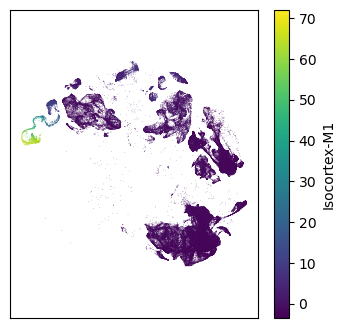

In [11]:
plot_umap(merged_df, color_col="Isocortex-M1")

In [12]:
def plot_multiple_umaps(data, modules, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots multiple UMAP visualizations for the specified modules.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.

    Returns:
        None
    """
    n_cols = 3  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(module)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=module)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

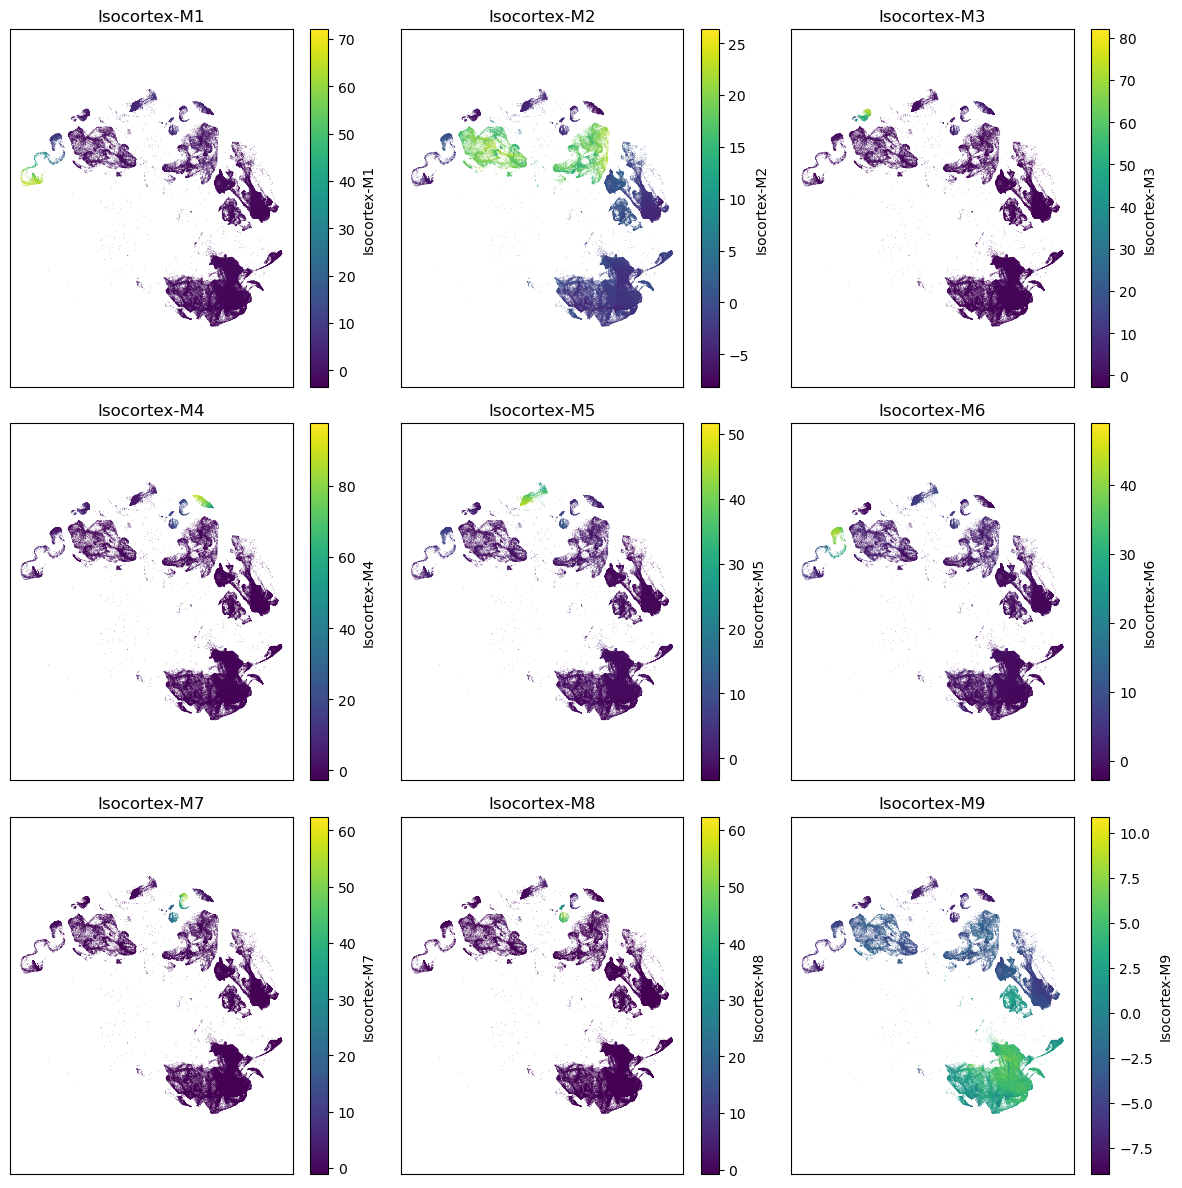

In [13]:
plot_multiple_umaps(merged_df, modules)

In [14]:
def plot_multiple_umaps_renamed(data, modules, module_names=None, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis", title=None):
    """
    Plots multiple UMAP visualizations for the specified modules with optional new names and a figure title.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        module_names (dict): Optional dictionary mapping old module names to new names for labeling.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.
        title (str): Title for the entire figure.

    Returns:
        None
    """
    n_cols = 3  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])

        # Use new name if provided, otherwise use the original module name
        title_text = module_names[module] if module_names and module in module_names else module
        ax.set_title(title_text)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=title_text)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Add a title to the entire figure if provided
    if title:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the title
    plt.show()

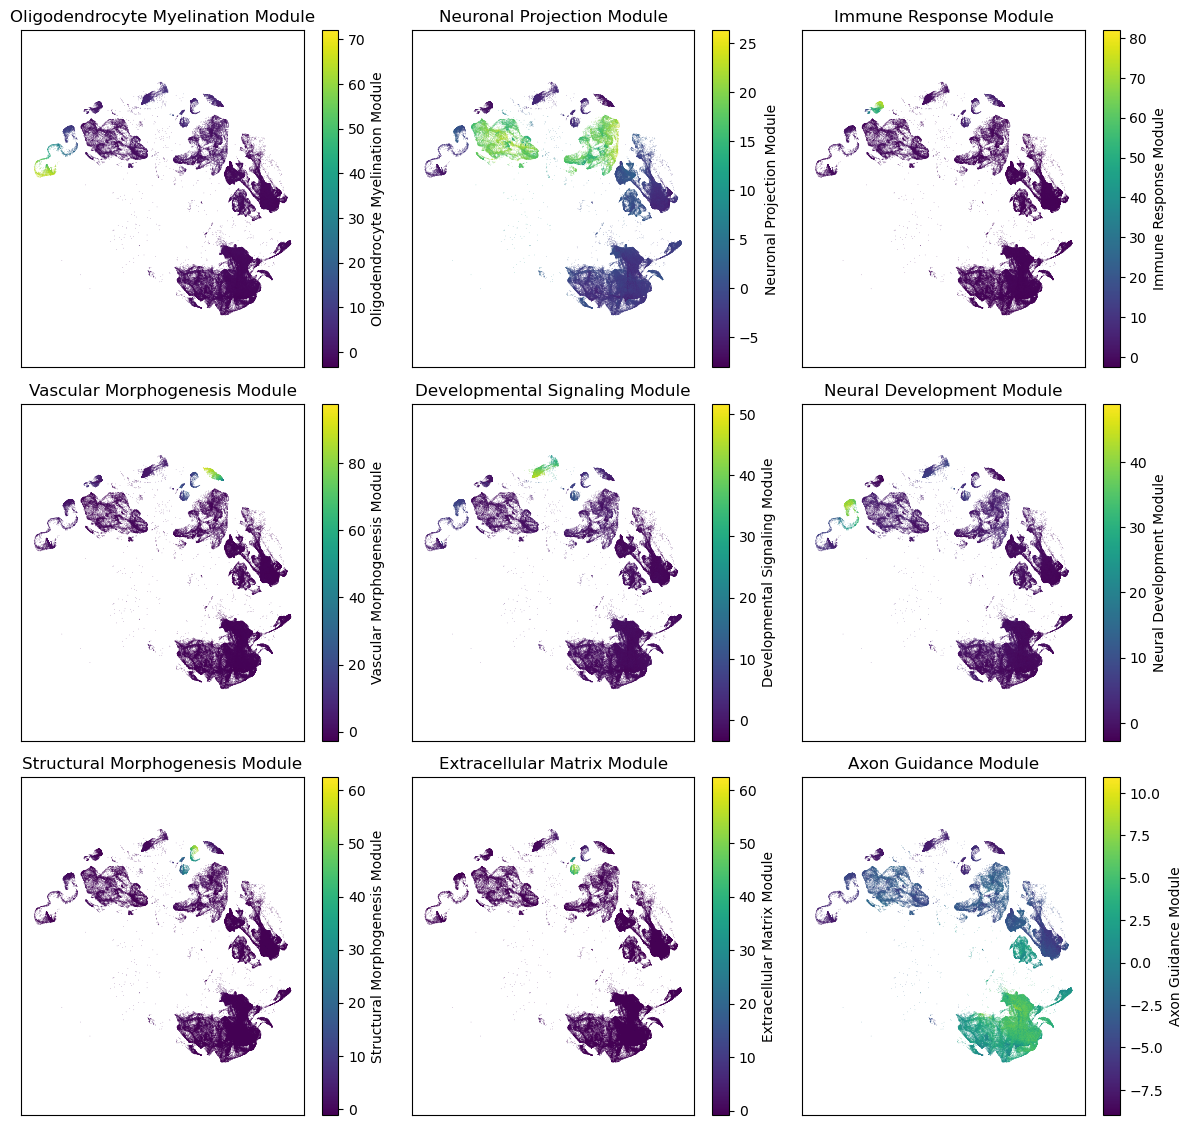

In [15]:
# output_file = "/home/momo/Pictures/ABCA/Isocortex_ME_UMAP.svg"
module_names = {
    "Isocortex-M1": "Oligodendrocyte Myelination Module",
    "Isocortex-M2": "Neuronal Projection Module",
    "Isocortex-M3": "Immune Response Module",
    "Isocortex-M4": "Vascular Morphogenesis Module",
    "Isocortex-M5": "Developmental Signaling Module",
    "Isocortex-M6": "Neural Development Module",
    "Isocortex-M7": "Structural Morphogenesis Module",
    "Isocortex-M8": "Extracellular Matrix Module",
    "Isocortex-M9": "Axon Guidance Module",
}
plot_multiple_umaps_renamed(merged_df, modules, module_names)

## Module Eigengenes across cell classes

In [16]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(merged_df[modules])
adata_vis.obs["class"] = merged_df["class"]  # Add cell type labels

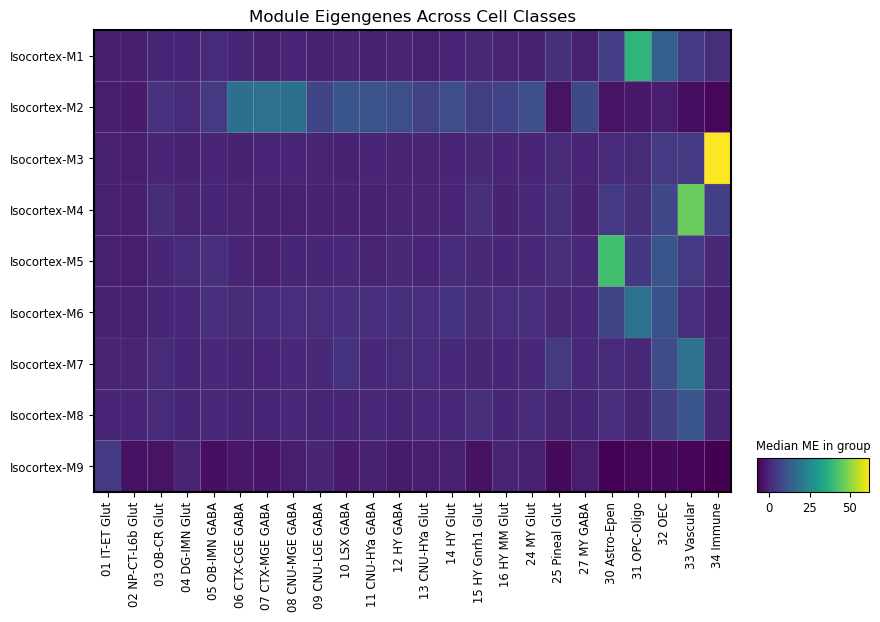

In [17]:
# Matrixplot
sc.pl.matrixplot(
    adata_vis,
    var_names=modules,
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

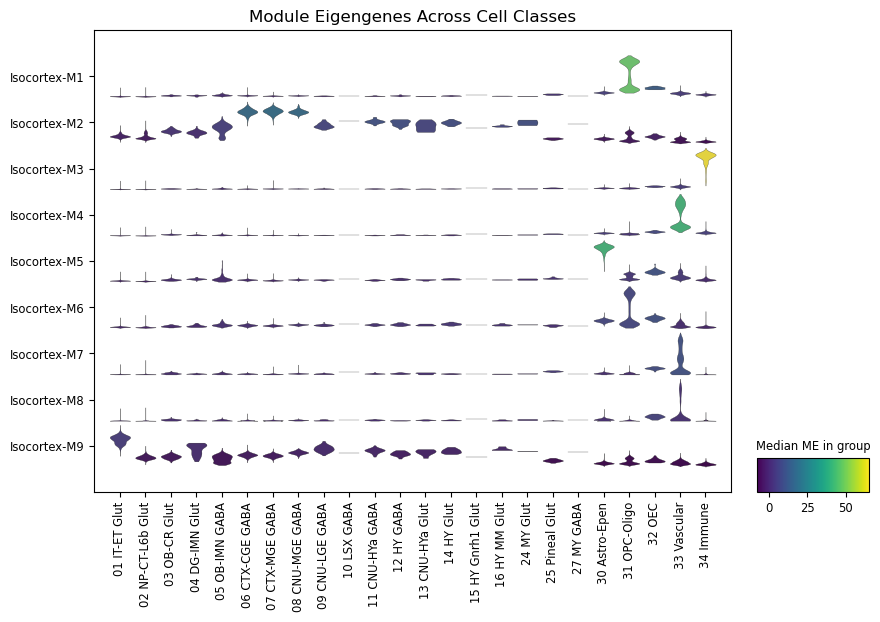

In [18]:
# Plot stacked violins
sc.pl.stacked_violin(
    adata_vis,
    var_names=modules,
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

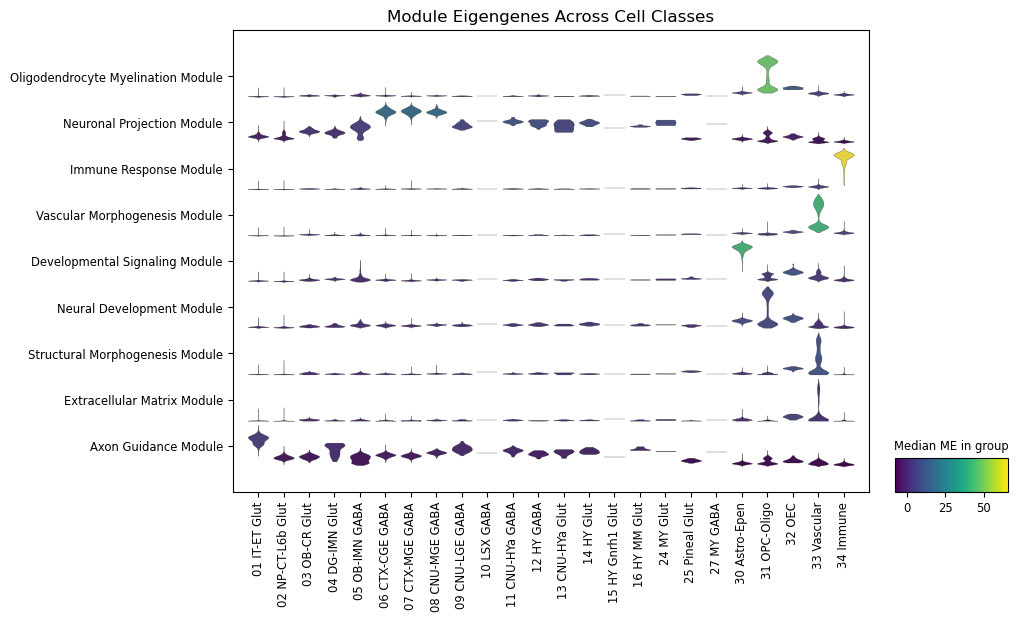

In [19]:
# Map old module names to new names for labeling
renamed_modules = [module_names[module] if module in module_names else module for module in modules]

# Create a new AnnData object with renamed modules
adata_vis_renamed = sc.AnnData(adata_vis.X)
adata_vis_renamed.obs = adata_vis.obs.copy()
adata_vis_renamed.var.index = renamed_modules

# Plot stacked violins with new module names
sc.pl.stacked_violin(
    adata_vis_renamed,
    var_names=renamed_modules,
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

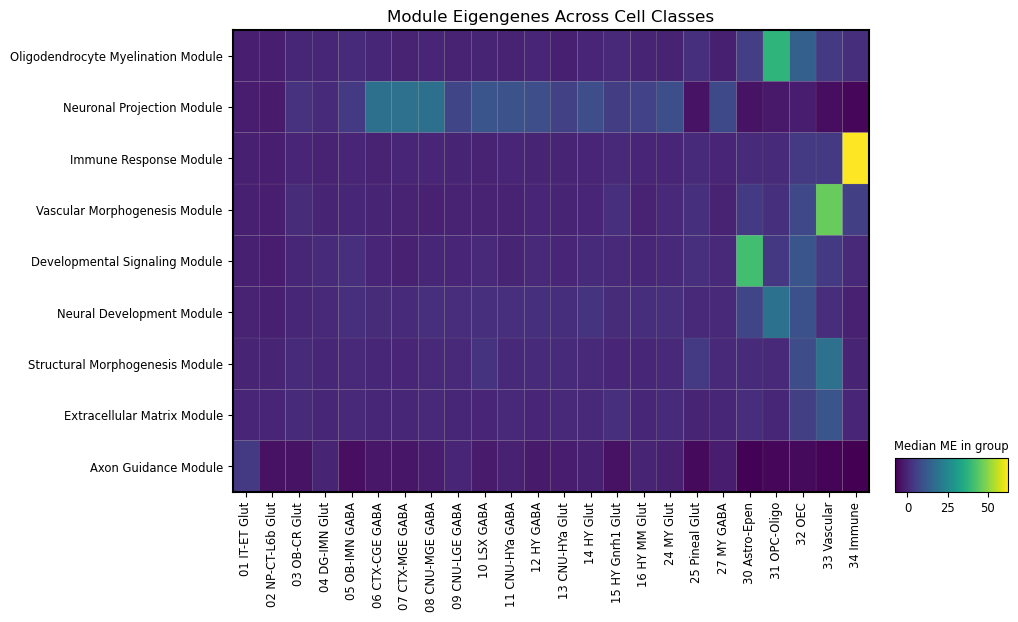

In [20]:
# Map old module names to new names for labeling
renamed_modules = [module_names[module] if module in module_names else module for module in modules]

# Create a new AnnData object with renamed modules
adata_vis_renamed = sc.AnnData(adata_vis.X)
adata_vis_renamed.obs = adata_vis.obs.copy()
adata_vis_renamed.var.index = renamed_modules

# Plot stacked violins with new module names
sc.pl.matrixplot(
    adata_vis_renamed,
    var_names=renamed_modules,
    groupby="class",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

# Quantifying module specificity

In [21]:
tau_scores = {}

for module in modules:
    tau_df = merged_df[["class", module]].copy()
    tau_df[module] = tau_df[module] - tau_df[module].min() + 1e-6  # Shift the eigengene values to ensure non-negativity

    # Compute average eigengene per cell class
    avg_expression = tau_df.groupby('class', observed=False)[module].mean()

    # Normalize by the maximum average expression
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr

    # Compute tau score
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    tau_scores[module] = tau

# Print Tau scores for all modules
for module, score in tau_scores.items():
    print(f"Tau specificity score for {module} module: {score:.3f}")

Tau specificity score for Isocortex-M1 module: 0.901
Tau specificity score for Isocortex-M2 module: 0.541
Tau specificity score for Isocortex-M3 module: 0.959
Tau specificity score for Isocortex-M4 module: 0.932
Tau specificity score for Isocortex-M5 module: 0.905
Tau specificity score for Isocortex-M6 module: 0.796
Tau specificity score for Isocortex-M7 module: 0.904
Tau specificity score for Isocortex-M8 module: 0.901
Tau specificity score for Isocortex-M9 module: 0.583
